# Generate synthetic data

## Functions

In [1]:
import bisect
import random
from math import exp

import numpy as np
import pandas as pd
from numpy.random import default_rng
from scipy.spatial import Voronoi, voronoi_plot_2d, cKDTree

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend import Legend


def readfile(filename):
    with open(filename, 'r') as f:
        return [line.rstrip() for line in f.readlines()]

# Cell type counts in snRNA-seq reference
counts = {
    'CCD': 3086,
    'DCT': 6490,
    'ENDO': 3850,
    'IMMUNE': 1013,
    'PODS': 215,
    'PT': 18109,
    'TAL': 8081,
    'UROTHELIUM': 161,
    'VSM': 3127
}

# Total number of cells in snRNA-seq reference
total = sum(counts.values())

# List of cell types sorted alphabetically
CELLTYPES = sorted(list(counts.keys()))

# List of cell type proportions
PROPORTIONS = [counts[x] / total for x in CELLTYPES]

# Cell types sorted by proportion
CELLTYPES = [x for _, x in sorted(zip(PROPORTIONS, CELLTYPES), reverse=True)]
PROPORTIONS = sorted(PROPORTIONS, reverse=True)

# Thresholds for cell type assignment
THRESHOLDS = PROPORTIONS.copy()
for i in range(1, len(THRESHOLDS)):
    THRESHOLDS[i] += THRESHOLDS[i - 1]

def get_classification(value):
    return CELLTYPES[bisect.bisect_right(THRESHOLDS, value)]

# Average expressions of each cell type
AVERAGE_EXPRESSIONS = {ct: np.loadtxt(f'./averages_filtered_human//{ct}-average.txt') for ct in CELLTYPES}

# List of genes
GENES = readfile('./genes_filtered_human.txt')

NUM_GENES = len(GENES)
NUM_CELLTYPES = len(CELLTYPES)

# Generate random point cloud with seed
def get_points(num_points=2500, dimensions=[1000, 1000], seed=None):
    rng = default_rng(seed)
    x = rng.uniform(low=0, high=dimensions[1], size=num_points)
    y = rng.uniform(low=0, high=dimensions[0], size=num_points)
    return list(zip(x, y))

# Generate random cell type classifications with seed
def get_classifications(num_points, seed=None):
    rng = default_rng(seed)
    values = rng.uniform(size=num_points)
    return list(map(get_classification, values))

# Generate gene expression
def generate_readings(spots, alpha, zeros=0, seed=None):
    ea = exp(-alpha)
    rng = default_rng(seed)
    lams = np.vstack([AVERAGE_EXPRESSIONS[ct] for ct in spots]) * ea
    vals = rng.poisson(lams, (len(spots), NUM_GENES))
    expr = np.vstack([vals[i] for i, _ in enumerate(spots)])

    if zeros > 0:
        indices = rng.choice(np.arange(len(spots)), size=int(len(spots) * zeros), replace=False)
        expr[indices] = 0

    return expr

# Convert expression to dataframe rows
def convert_to_rows(coords, expression_matrix):
    reads = zip(*np.where(expression_matrix > 0))
    for i, j in reads:
        x, y = coords[i]
        gene = GENES[j]
        yield {'geneID': gene, 'x': x, 'y': y, 'MIDCounts': expression_matrix[i, j]}

# Create dataframe of gene expression
def create_expression_df(spots, spot_types, alpha, zeros=0, seed=None):
    expr = generate_readings(spot_types, alpha, zeros=zeros, seed=seed)
    return pd.DataFrame(convert_to_rows(spots, expr))

# Run entire process of generating synthetic data
def get_everything(num_cells=2500, dimensions=(1000, 1000), alpha=7, zeros=0, seed_points=None, seed_classify=None, seed_readings=None):
    cells = get_points(num_cells, dimensions, seed=seed_points)
    celltypes = get_classifications(num_cells, seed=seed_classify)

    spots = np.array(list(itertools.product(range(dimensions[0]), range(dimensions[1]))))

    voronoi_kdtree = cKDTree(cells)
    _, spot_regions = voronoi_kdtree.query(spots, k=1)

    spot_types = [celltypes[i] for i in spot_regions]

    df = create_expression_df(spots, spot_types, alpha, zeros, seed=seed_readings)

    spot_cells = np.empty(dimensions)
    for ((x, y), cell) in zip(spots, spot_regions):
        spot_cells[x, y] = cell

    ct_grid = np.empty(dimensions)
    for ((x, y), ct) in zip(spots, spot_types):
        ct_grid[x, y] = CELLTYPES.index(ct)

    return cells, celltypes, spot_cells, ct_grid, df


In [2]:
from collections import Counter
import numpy as np

def sparsify_data(spots, spot_regions, spot_types, min_size=800, random_remove_ratio=0.05, random_seed=123):
    
    region_counts = Counter(spot_regions)
    valid_cells = {cell for cell, count in region_counts.items() if count >= min_size}
    print(f"Cells remaining after min_size filtering: {len(valid_cells)}")

    rng = np.random.default_rng(random_seed)
    num_to_remove = int(random_remove_ratio * len(valid_cells))
    to_remove = set(rng.choice(list(valid_cells), size=num_to_remove, replace=False))
    valid_cells -= to_remove
    print(f"Cells remaining after random removal of {random_remove_ratio*100}%: {len(valid_cells)}")

    mask = np.array([cell in valid_cells for cell in spot_regions])

    filtered_spots = spots[mask]
    filtered_spot_types = [spot_types[i] for i, keep in enumerate(mask) if keep]
    filtered_spot_regions = np.array([spot_regions[i] for i, keep in enumerate(mask) if keep])

    return filtered_spots, filtered_spot_types, filtered_spot_regions, valid_cells


## without modified celltypes

In [7]:
import itertools
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# PARAMETERS
num_cells = 2500
dimensions = (2000, 2000)
alpha = 7
zeros = 0.7
change_ratio = 0.1

seed_points = 42
seed_classify = 43
seed_modify = 44
readout_seeds = [101, 102, 103, 104, 105, 106]

CELLTYPES = ['PT', 'TAL', 'DCT', 'ENDO', 'VSM', 'CCD', 'IMMUNE', 'PODS', 'UROTHELIUM']

# Generate base cells and celltypes with controlled seeds
cells = get_points(num_cells, dimensions, seed=seed_points)
celltypes = get_classifications(num_cells, seed=seed_classify)

# Modify some celltypes randomly (not used here in final output)
modified_celltypes = celltypes.copy()
rng_modify = np.random.default_rng(seed_modify)
num_changes = int(change_ratio * num_cells)
change_indices = rng_modify.choice(num_cells, size=num_changes, replace=False)

for idx in change_indices:
    original = modified_celltypes[idx]
    alternatives = [ct for ct in CELLTYPES if ct != original]
    modified_celltypes[idx] = rng_modify.choice(alternatives)

# Generate spots on grid
spots = np.array(list(itertools.product(range(dimensions[0]), range(dimensions[1]))))

# Assign spots to closest cell
kdtree = cKDTree(cells)
_, spot_regions = kdtree.query(spots, k=1)

# Assign initial cell types
spot_types_1 = [celltypes[i] for i in spot_regions]

# Sparsify data
filtered_spots, filtered_spot_types_1, filtered_spot_regions, valid_cells = sparsify_data(
    spots, spot_regions, spot_types_1,
    min_size=600,
    random_remove_ratio=0.05,
    random_seed=123
)

# Generate expression matrices and dataframes (all based on original celltypes)
expression_matrices = []
dfs = []

for i, seed in enumerate(readout_seeds):
    z = i + 1
    current_types = filtered_spot_types_1
    current_spots = filtered_spots

    expr_matrix = generate_readings(current_types, alpha, zeros=zeros, seed=seed)
    expression_matrices.append(expr_matrix)

    df = pd.DataFrame(convert_to_rows(current_spots, expr_matrix))
    df["z"] = z
    dfs.append(df)

df_unmod = pd.concat(dfs, ignore_index=True)


Cells remaining after min_size filtering: 2285
Cells remaining after random removal of 5.0%: 2171


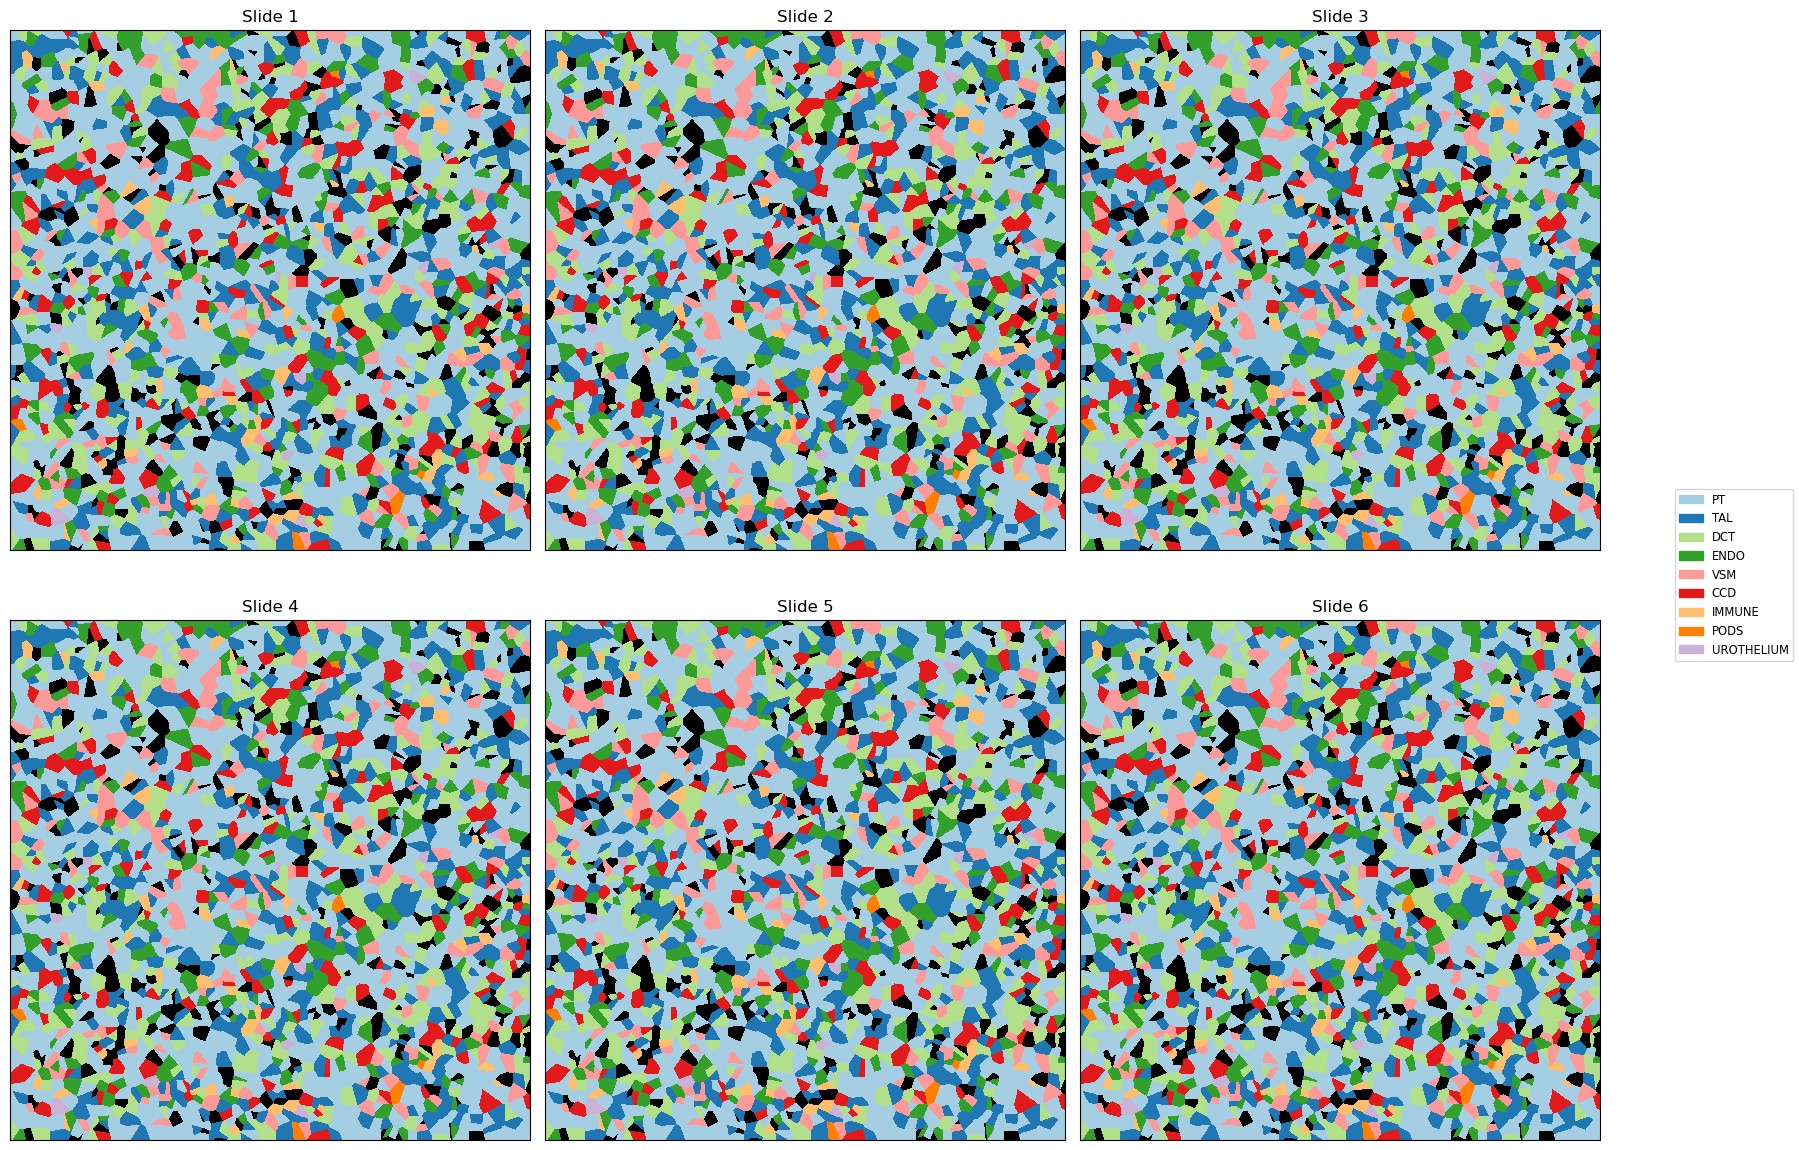

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

height, width = dimensions
celltype_to_idx = {ct: i for i, ct in enumerate(CELLTYPES)}

ACTUAL_COLOURS = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00','#cab2d6']
celltype_to_rgb = np.array([tuple(int(c[i+1:i+3], 16) for i in (0, 2, 4)) for c in ACTUAL_COLOURS], dtype=np.uint8)

def spots_to_rgb_image(spots, spot_types, height, width):
    img = np.zeros((height, width, 3), dtype=np.uint8)
    for (x, y), ct in zip(spots, spot_types):
        img[y, x] = celltype_to_rgb[celltype_to_idx[ct]]
    return img

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i in range(6):
    z = i + 1
    ax = axes[i]

    rgb_img = spots_to_rgb_image(filtered_spots, filtered_spot_types_1, height, width)

    ax.imshow(rgb_img, interpolation='none', origin='lower')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Slide {z}')

legend_patches = [mpatches.Patch(color=ACTUAL_COLOURS[i], label=ct) for i, ct in enumerate(CELLTYPES)]
fig.legend(handles=legend_patches, loc='center right', fontsize='small')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


## modified Celltypes

In [5]:


# PARAMETERS
num_cells = 2500
dimensions = (2000, 2000)
alpha = 7
zeros = 0.7
change_ratio = 0.1

seed_points = 42
seed_classify = 43
seed_modify = 44
readout_seeds = [101, 102, 103, 104, 105, 106]

CELLTYPES = ['PT', 'TAL', 'DCT', 'ENDO', 'VSM', 'CCD', 'IMMUNE', 'PODS', 'UROTHELIUM']

# Generate base cells and celltypes with controlled seeds
cells = get_points(num_cells, dimensions, seed=seed_points)
celltypes = get_classifications(num_cells, seed=seed_classify)

# Modify some celltypes randomly
modified_celltypes = celltypes.copy()
rng_modify = np.random.default_rng(seed_modify)
num_changes = int(change_ratio * num_cells)
change_indices = rng_modify.choice(num_cells, size=num_changes, replace=False)

for idx in change_indices:
    original = modified_celltypes[idx]
    alternatives = [ct for ct in CELLTYPES if ct != original]
    modified_celltypes[idx] = rng_modify.choice(alternatives)

# Generate spots on grid
spots = np.array(list(itertools.product(range(dimensions[0]), range(dimensions[1]))))

# Assign spots to closest cell
kdtree = cKDTree(cells)
_, spot_regions = kdtree.query(spots, k=1)

# Assign initial cell types
spot_types_1 = [celltypes[i] for i in spot_regions]

# Sparsify data (assumes sparsify_data is defined)
filtered_spots, filtered_spot_types_1, filtered_spot_regions, valid_cells = sparsify_data(
    spots, spot_regions, spot_types_1,
    min_size=600,
    random_remove_ratio=0.05,
    random_seed=123
)

# Modify spot types post-sparsification
spot_types_2 = [modified_celltypes[i] for i in filtered_spot_regions]

# Generate expression matrices and dataframes
expression_matrices = []
dfs = []

for i, seed in enumerate(readout_seeds):
    z = i + 1

    if z <= 3:
        current_types = filtered_spot_types_1
        current_spots = filtered_spots
    else:
        current_types = spot_types_2
        current_spots = filtered_spots

    expr_matrix = generate_readings(current_types, alpha, zeros=zeros, seed=seed)
    expression_matrices.append(expr_matrix)

    df = pd.DataFrame(convert_to_rows(current_spots, expr_matrix))
    df["z"] = z
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)


Cells remaining after min_size filtering: 2285
Cells remaining after random removal of 5.0%: 2171


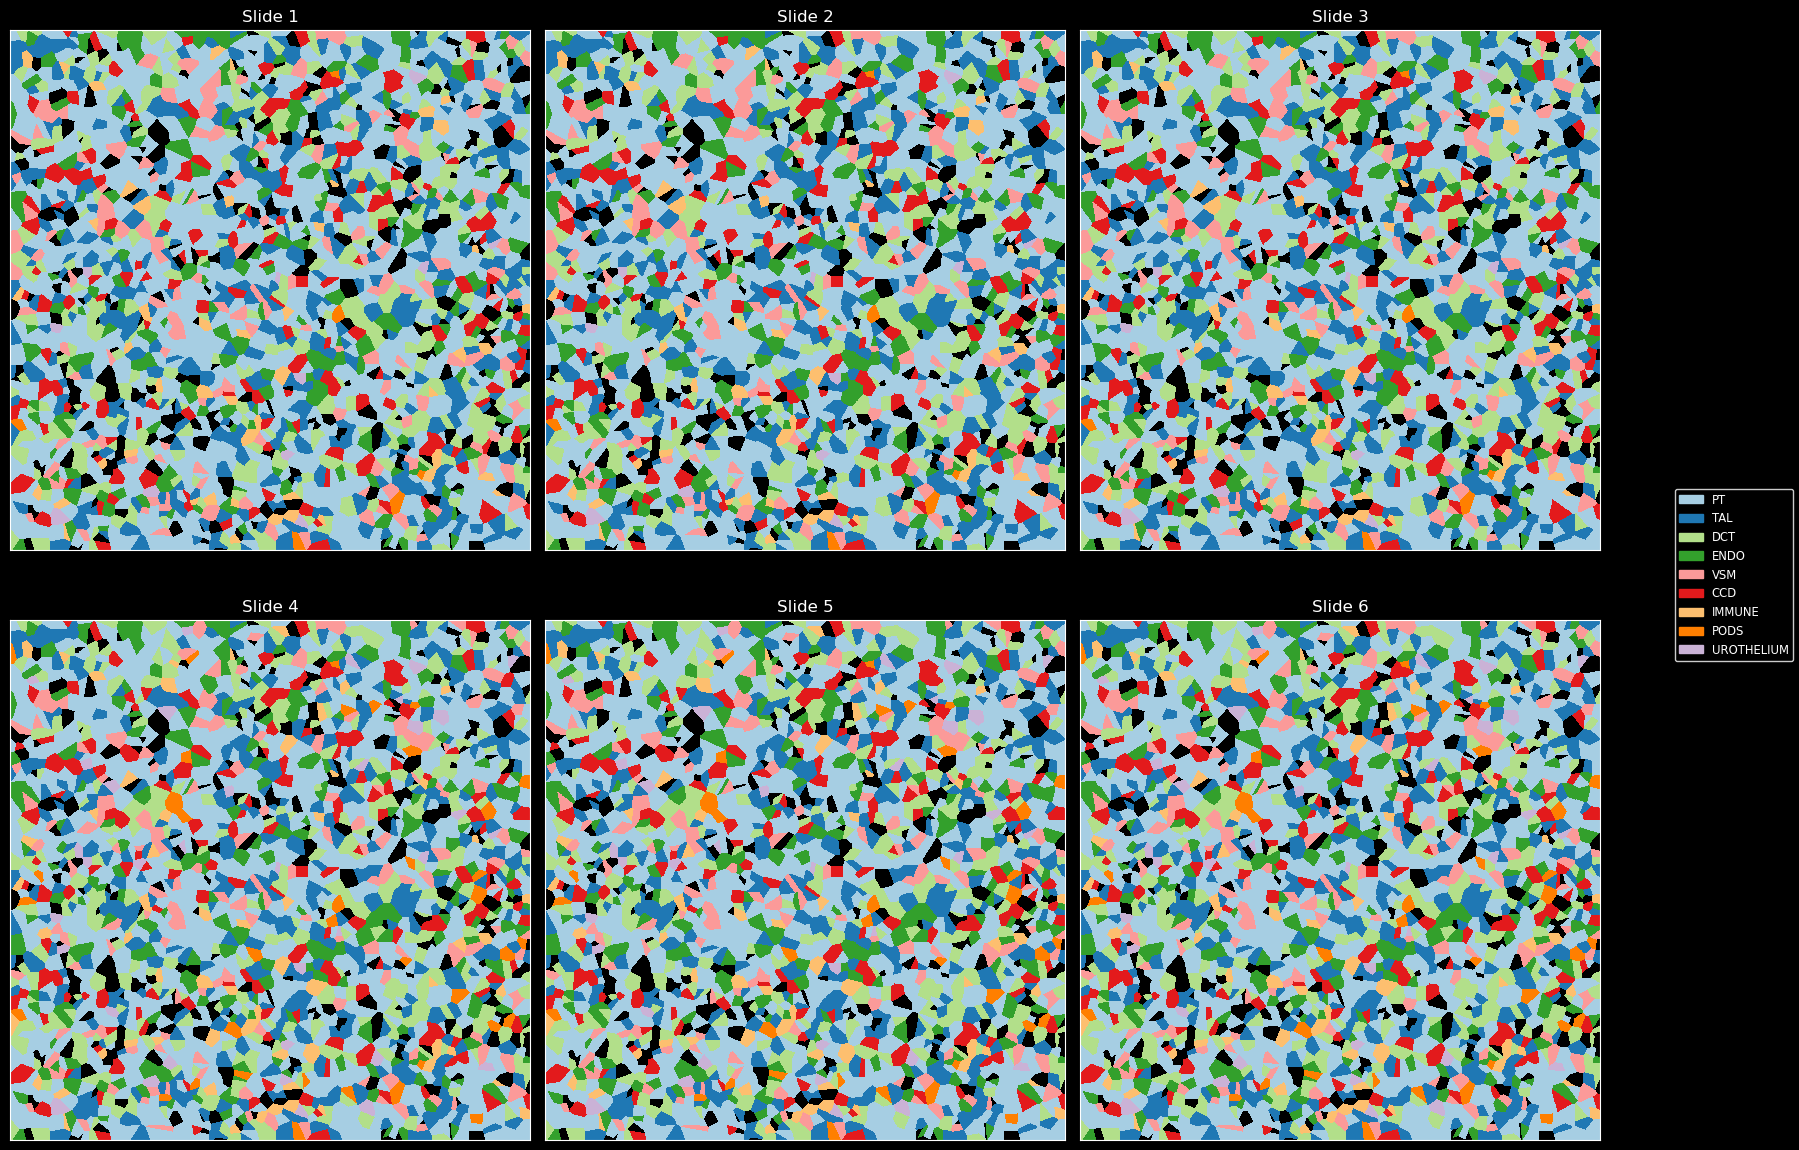

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

height, width = dimensions
celltype_to_idx = {ct: i for i, ct in enumerate(CELLTYPES)}

ACTUAL_COLOURS = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00','#cab2d6']
celltype_to_rgb = np.array([tuple(int(c[i+1:i+3], 16) for i in (0, 2, 4)) for c in ACTUAL_COLOURS], dtype=np.uint8)

def spots_to_rgb_image(spots, spot_types, height, width):
    img = np.zeros((height, width, 3), dtype=np.uint8)
    for (x, y), ct in zip(spots, spot_types):
        img[y, x] = celltype_to_rgb[celltype_to_idx[ct]]
    return img

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Set black background for entire figure
fig.patch.set_facecolor('black')

for i in range(6):
    z = i + 1
    ax = axes[i]
    ax.set_facecolor('black')  # black background for each subplot

    if z <= 3:
        rgb_img = spots_to_rgb_image(filtered_spots, filtered_spot_types_1, height, width)
    else:
        rgb_img = spots_to_rgb_image(filtered_spots, spot_types_2, height, width)

    ax.imshow(rgb_img, interpolation='none', origin='lower')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Slide {z}', color='white')  # Title text color

    # Set spines (axes borders) to white
    for spine in ax.spines.values():
        spine.set_color('white')

# Create legend with white text and black background
legend_patches = [mpatches.Patch(color=ACTUAL_COLOURS[i], label=ct) for i, ct in enumerate(CELLTYPES)]
legend = fig.legend(handles=legend_patches, loc='center right', fontsize='small', frameon=True)
legend.get_frame().set_facecolor('black')
legend.get_frame().set_edgecolor('white')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("synthetic_cell_map_modified_unmodified.pdf", dpi=600, bbox_inches='tight')
plt.show()


/tmp/ipykernel_1137071/4222350865.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


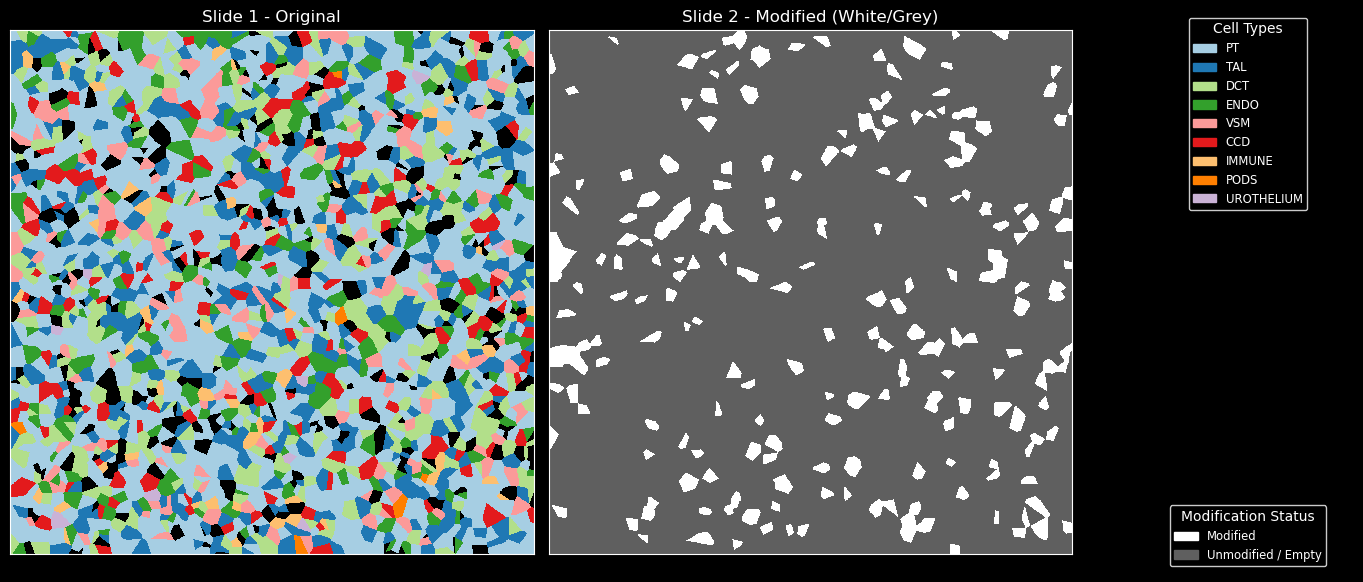

In [12]:

height, width = dimensions
celltype_to_idx = {ct: i for i, ct in enumerate(CELLTYPES)}

ACTUAL_COLOURS = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99',
                  '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6']
celltype_to_rgb = np.array([
    tuple(int(c[i+1:i+3], 16) for i in (0, 2, 4)) for c in ACTUAL_COLOURS
], dtype=np.uint8)

GREY_RGB = np.array([95, 95, 95], dtype=np.uint8)      # unmodified + empty
WHITE_RGB = np.array([255, 255, 255], dtype=np.uint8)  # modified

def spots_to_rgb_image(spots, spot_types, height, width):
    img = np.zeros((height, width, 3), dtype=np.uint8)
    for (x, y), ct in zip(spots, spot_types):
        img[y, x] = celltype_to_rgb[celltype_to_idx[ct]]
    return img

def spots_to_modified_rgb_image(spots, original_types, modified_types, height, width):
    img = np.full((height, width, 3), GREY_RGB, dtype=np.uint8)  # default = unmodified/empty
    for (x, y), orig_ct, mod_ct in zip(spots, original_types, modified_types):
        if orig_ct != mod_ct:
            img[y, x] = WHITE_RGB
    return img

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('black')

# Original
rgb_img_orig = spots_to_rgb_image(filtered_spots, filtered_spot_types_1, height, width)
axes[0].imshow(rgb_img_orig, interpolation='none', origin='lower')
axes[0].set_title('Slide 1 - Original', color='white')
axes[0].set_facecolor('black')
axes[0].set_xticks([])
axes[0].set_yticks([])
for spine in axes[0].spines.values():
    spine.set_color('white')

# Modified (white = changed, grey = same or empty)
rgb_img_mod = spots_to_modified_rgb_image(filtered_spots, filtered_spot_types_1, spot_types_2, height, width)
axes[1].imshow(rgb_img_mod, interpolation='none', origin='lower')
axes[1].set_title('Slide 2 - Modified (White/Grey)', color='white')
axes[1].set_facecolor('black')
axes[1].set_xticks([])
axes[1].set_yticks([])
for spine in axes[1].spines.values():
    spine.set_color('white')

# Cell type legend
legend_patches_ct = [mpatches.Patch(color=ACTUAL_COLOURS[i], label=ct) for i, ct in enumerate(CELLTYPES)]
labels_ct = CELLTYPES

# Modification legend
legend_patches_mod = [
    mpatches.Patch(color='#FFFFFF', label='Modified'),
    mpatches.Patch(color='#5F5F5F', label='Unmodified / Empty')
]
labels_mod = ['Modified', 'Unmodified / Empty']

# Adjust for legend space
fig.subplots_adjust(right=0.78)

# Right-side legend container
ax_leg = fig.add_axes([0.82, 0.1, 0.15, 0.8])
ax_leg.axis('off')

# Create legends
leg1 = Legend(ax_leg, legend_patches_ct, labels_ct,
              title='Cell Types', loc='upper center', fontsize='small', title_fontsize='medium', frameon=True)

leg2 = Legend(ax_leg, legend_patches_mod, labels_mod,
              title='Modification Status', loc='lower center', fontsize='small', title_fontsize='medium', frameon=True)

ax_leg.add_artist(leg1)
ax_leg.add_artist(leg2)

# Legend styling
for leg in [leg1, leg2]:
    leg.get_frame().set_facecolor('black')
    leg.get_frame().set_edgecolor('white')
    for text in leg.get_texts():
        text.set_color('white')
    leg.get_title().set_color('white')

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.savefig("modified_vs_original_fixed_white_grey.pdf", dpi=600, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
